<a href="https://colab.research.google.com/github/eduardosilvintec/proyecto_integrador_equipo27/blob/main/Avance1.%2327.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Project Name:** Mushroom Farm Monitoring System (SMC)

**Company:** South Mill Champs

**Professor:** Dra. María de la Paz Rico

**Team 27:**

Arantxa Stephania Coronel González A01620352

Roberto Ferro Salinas A01374849

Eduardo Rodrigo Silva Orozco A0179593

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Data Structure

An overall description of the data structure and data types is included. Descriptive statistics are obtained for all variables in the dataset. For categorical variables, class frequencies are determined. Missing values are identified.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Excel dataset.
# The file contains hierarchical (multi-level) column headers, therefore the first three rows are explicitly read as a MultiIndex structure.
file_path = '/content/drive/MyDrive/Proyecto integrador MNA Ene 2026/Colab Notebook/Flush Yield 2025 - Encrypted.xlsx'
df = pd.read_excel(file_path, header=[0, 1, 2])

# Flatten the multi-index columns into a single string name
df.columns = ['_'.join(str(level) for level in col if 'Unnamed' not in str(level)).strip('_') for col in df.columns]

# Basic info
print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (266, 72)


,SerialKey,Compost Information_Spawn Rate,Compost Information_Supplement Rate,Compost Information_Water Added,Farm Filling Information_Sqft Filled,Farm Filling Information_Missing Sections,Farm Filling Information_Sqm Filled,Farm Filling Information_Tons,Farm Filling Information_Filled heights (cm),Farm Filling Information_Filled kg,...,3rd Flush_total hours,3rd Flush_lbs/hr,3rd Flush_lbs/sqft,3rd Flush_lbs/ton,Total_lbs,Total_lbs/hour,Total_lbs/sqft,Total_lbs/ton,Total_Target,"Room Finished ( Type ""Y"" when finished)"
0,CT001,15.359838,0.0129,6.7,4673.000000,NaN,434.132293,39.26,28,39260.0,...,NaN,NaN,0.783313,93.235354,33212.69,NaN,7.107359,845.967652,820,Y
1,CT002,14.925547,0.0126,7.08,4673.000000,NaN,434.132293,41.37,26,41370.0,...,NaN,NaN,0.727017,82.121102,32741.15,NaN,7.006452,791.422528,820,Y
2,CT003,15.800000,1.3%/1.22%,7.81/9.16,4642.712051,1.4,431.318474,38.89,32,38890.0,...,NaN,NaN,0.974588,116.346876,31991.59,NaN,6.890712,822.617382,820,Y
3,CT004,14.700000,0.0122,9.16,4673.000000,NaN,434.132293,39.79,27,39790.0,...,NaN,NaN,0.840591,98.720281,32193.04,NaN,6.889159,809.073637,820,Y
4,CT005,15.200000,0.0127,8.15,4673.000000,NaN,434.132293,38.69,27,38690.0,...,NaN,NaN,0.839341,101.376066,29322.94,NaN,6.274971,757.894546,820,Y


In [ ]:
# Display the general structure of the dataset, including data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 266 entries, 0 to 265
Data columns (total 72 columns):
 #   Column                                         Non-Null Count  Dtype         
---  ------                                         --------------  -----         
 0   SerialKey                                      175 non-null    object        
 1   Compost Information_Spawn Rate                 60 non-null     float64       
 2   Compost Information_Supplement Rate            69 non-null     object        
 3   Compost Information_Water Added                68 non-null     object        
 4   Farm Filling Information_Sqft Filled           266 non-null    float64       
 5   Farm Filling Information_Missing Sections      87 non-null     float64       
 6   Farm Filling Information_Sqm Filled            266 non-null    float64       
 7   Farm Filling Information_Tons                  174 non-null    float64       
 8   Farm Filling Information_Filled heights (cm)   175 non-null 

**Identification of missing values**

In [ ]:
# Calculate the number and percentage of missing values per variable
missing_summary = pd.DataFrame({
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': (df.isnull().sum() / len(df)) * 100
}).sort_values(by='Missing_Count', ascending=False)

missing_summary

,Missing_Count,Missing_Percentage
Total_lbs/hour,266,100.0
2nd Flush_lbs/hr,266,100.0
3rd Flush_lbs/hr,266,100.0
3rd Flush_total hours,266,100.0
1st Flush_Total Hours,266,100.0
...,...,...
3rd Flush_lbs,0,0.0
Total_lbs,0,0.0
3rd Flush_lbs/sqft,0,0.0
Total_lbs/sqft,0,0.0


**Separation of numerical and categorical variables**

In [ ]:
# Identify numerical, datetime, and categorical variables based on data types
numerical_vars = df.select_dtypes(include=[np.number]).columns
datetime_vars = df.select_dtypes(include=['datetime64[ns]']).columns
categorical_vars = df.select_dtypes(exclude=[np.number, 'datetime64[ns]']).columns

# Display the number and names of numerical variables
print(f"Number of numerical variables: {len(numerical_vars)}")
print("\nNumerical variables:")
for var in numerical_vars:
    print(f"- {var}")

# Display the number and names of datetime variables
print(f"\nNumber of datetime variables: {len(datetime_vars)}")
print("\nDatetime variables:")
for var in datetime_vars:
    print(f"- {var}")

# Display the number and names of categorical variables
print(f"\nNumber of categorical variables: {len(categorical_vars)}")
print("\nCategorical variables:")
for var in categorical_vars:
    print(f"- {var}")

Number of numerical variables: 65

Numerical variables:
- Compost Information_Spawn Rate
- Farm Filling Information_Sqft Filled
- Farm Filling Information_Missing Sections
- Farm Filling Information_Sqm Filled
- Farm Filling Information_Tons
- Farm Filling Information_Filled kg
- Farm Filling Information_Fill rate kg/m²
- Stagger/Pincount Info_Picking Day_Actual
- Stagger/Pincount Info_Picking Day_Target
- Stagger/Pincount Info_Pin Count_Actual
- Stagger/Pincount Info_Pin Count_Target
- Stagger/Pincount Info_Stagger_Actual
- Stagger/Pincount Info_Stagger_Target
- Watering_Water Applied (L)_1st Flush
- Watering_Water Applied (L)_2nd Flush
- Watering_Water Applied (L)_3rd Flush
- Watering_Water Applied (L)_Total (L)
- 1st Flush_Day 1
- 1st Flush_Sep lbs
- 1st Flush_Day 2
- 1st Flush_Sep lbs
- 1st Flush_Day 3
- 1st Flush_Day 4
- 1st Flush_Day 5
- 1st Flush_Day 6
- 1st Flush_Day 7
- 1st Flush_Sep %
- 1st Flush_lbs
- 1st Flush_Total Hours
- 1st Flush_lbs/hr
- 1st Flush_lbs/sqft
- 1st Flush_

**Descriptive statistics for numerical variables**

In [ ]:
# Compute descriptive statistics for all numerical variables
numerical_description = df[numerical_vars].describe().T
numerical_description

,count,mean,std,min,25%,50%,75%,max
Compost Information_Spawn Rate,60.0,15.051961,0.819046,13.292673,14.587278,15.015348,15.710668,17.187976
Farm Filling Information_Sqft Filled,266.0,4568.456152,433.084788,2076.890120,4629.731502,4673.000000,4673.000000,4673.000000
Farm Filling Information_Missing Sections,87.0,14.774713,32.958050,1.000000,2.000000,2.000000,2.000000,120.000000
Farm Filling Information_Sqm Filled,266.0,424.419932,40.234559,192.947800,430.112551,434.132293,434.132293,434.132293
Farm Filling Information_Tons,174.0,37.237874,4.829647,15.960000,36.532500,38.185000,39.380000,45.750000
...,...,...,...,...,...,...,...,...
Total_lbs,266.0,19775.474737,15909.675445,0.000000,0.000000,30528.755000,33519.875000,37156.920000
Total_lbs/hour,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Total_lbs/sqft,266.0,4.355725,3.430642,0.000000,0.000000,6.663431,7.216355,8.266538
Total_lbs/ton,174.0,812.509549,200.491712,0.000000,809.676230,863.335895,903.286612,1090.925426


**Class frequency analysis for categorical variables**

In [ ]:
# Compute and display the top 10 class frequencies for each categorical variable
categorical_frequencies = {
    col: df[col].value_counts(dropna=False).head(10)
    for col in categorical_vars
}

# Print the top 10 frequencies per categorical variable
for col, freq in categorical_frequencies.items():
    print(f"\nTop 10 frequencies for categorical variable: {col}")
    print(freq)


Top 10 frequencies for categorical variable: SerialKey
SerialKey
NaN      91
CT001     1
CT003     1
CT002     1
CT005     1
CT006     1
CT007     1
CT004     1
CT009     1
CT010     1
Name: count, dtype: int64

Top 10 frequencies for categorical variable: Compost Information_Supplement Rate
Compost Information_Supplement Rate
NaN        197
0.0127       4
0.01495      4
0.0152       3
0.0125       3
0.01305      2
0.0122       2
0.0129       2
0.0144       2
0.01525      2
Name: count, dtype: int64

Top 10 frequencies for categorical variable: Compost Information_Water Added
Compost Information_Water Added
NaN     198
5.99      3
8.15      2
5.81      2
0.22      2
0.18      2
0.29      2
6.44      2
3.09      2
5.71      2
Name: count, dtype: int64

Top 10 frequencies for categorical variable: Farm Filling Information_Filled heights (cm) 
Farm Filling Information_Filled heights (cm) 
NaN     91
28      57
29      27
30      25
27      19
31      17
32       9
33       5
28.5     4
3

# Univariable Analysis

Visualization techniques (histograms, boxplots, bar charts) are used according to the data type and measurement scale.

Univariable analysis for numerical variables
Histograms and boxplots

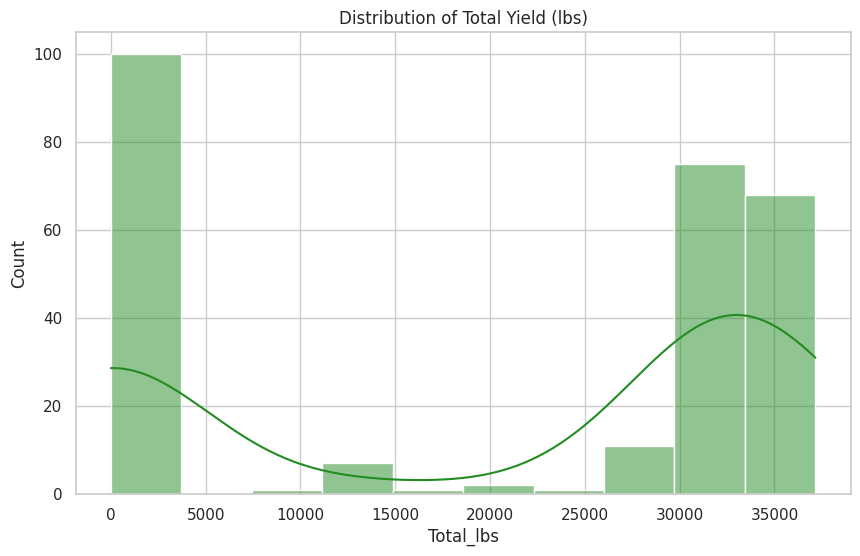

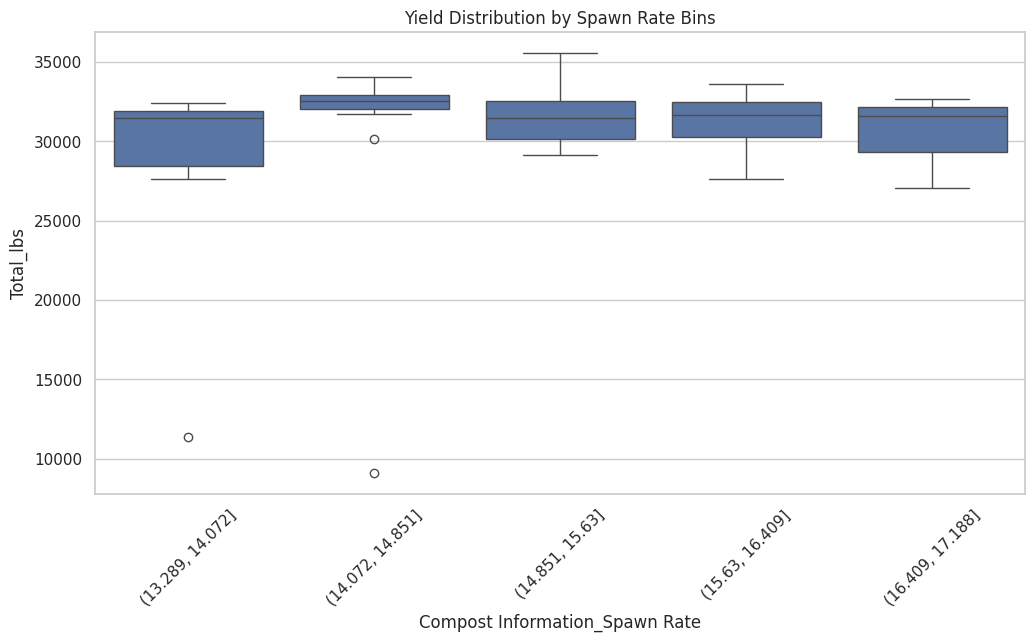

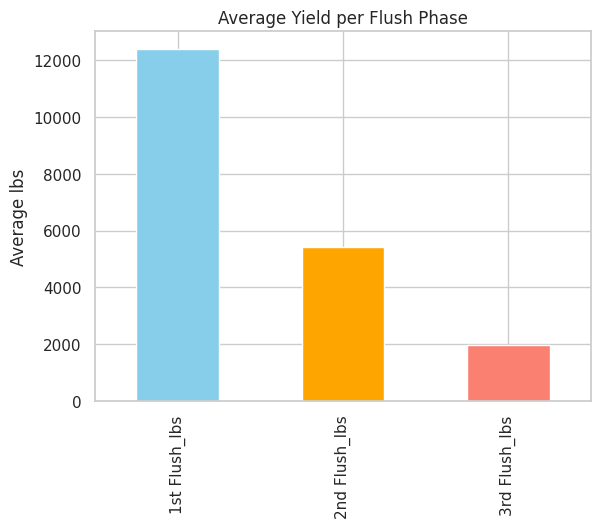

In [ ]:
# Set visual style
sns.set_theme(style="whitegrid")

# 1. Histogram: Distribution of Total Yield (lbs)
plt.figure(figsize=(10, 6))
sns.histplot(df['Total_lbs'], kde=True, color='forestgreen')
plt.title('Distribution of Total Yield (lbs)')
plt.show()

# 2. Boxplot: Comparing Yield across different Spawn Rates (or similar)
plt.figure(figsize=(12, 6))
sns.boxplot(x=pd.cut(df['Compost Information_Spawn Rate'], bins=5), y=df['Total_lbs'])
plt.title('Yield Distribution by Spawn Rate Bins')
plt.xticks(rotation=45)
plt.show()

# 3. Bar Chart: Average 1st vs 2nd vs 3rd Flush
flush_means = df[['1st Flush_lbs', '2nd Flush_lbs', '3rd Flush_lbs']].mean()
flush_means.plot(kind='bar', color=['skyblue', 'orange', 'salmon'])
plt.title('Average Yield per Flush Phase')
plt.ylabel('Average lbs')
plt.show()


Univariable analysis for categorical variables
Bar charts (Top 10 categories)

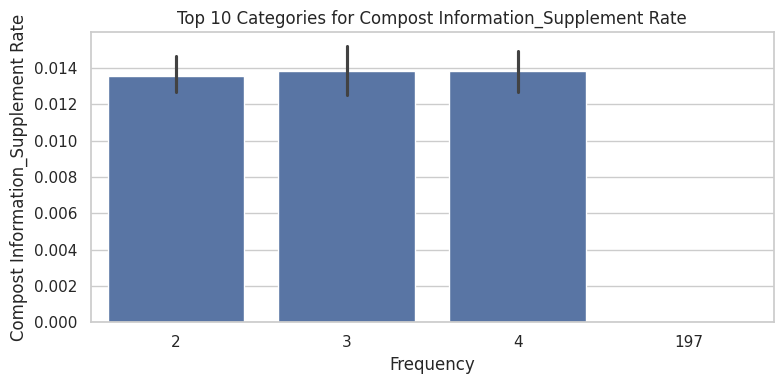

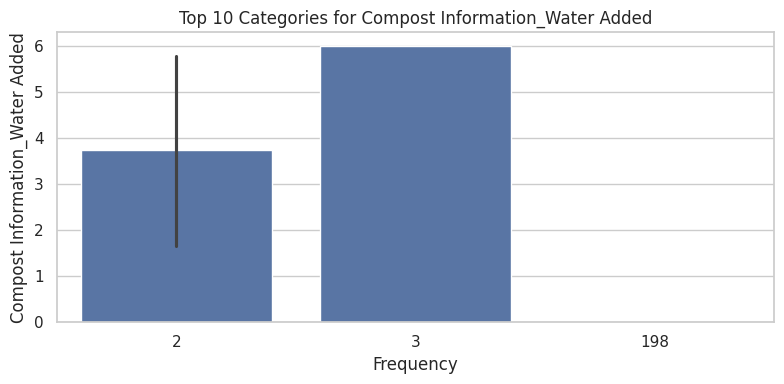

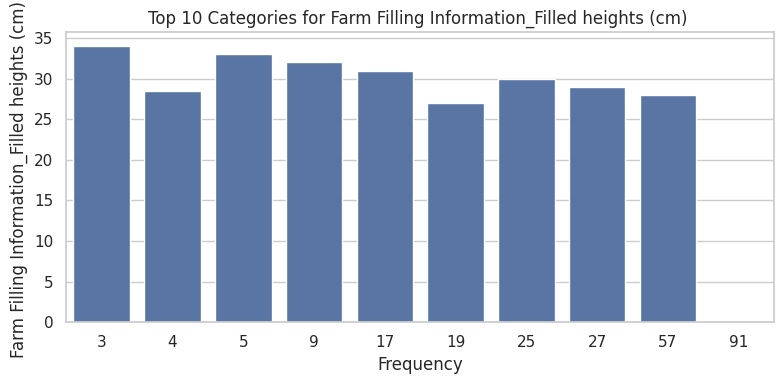

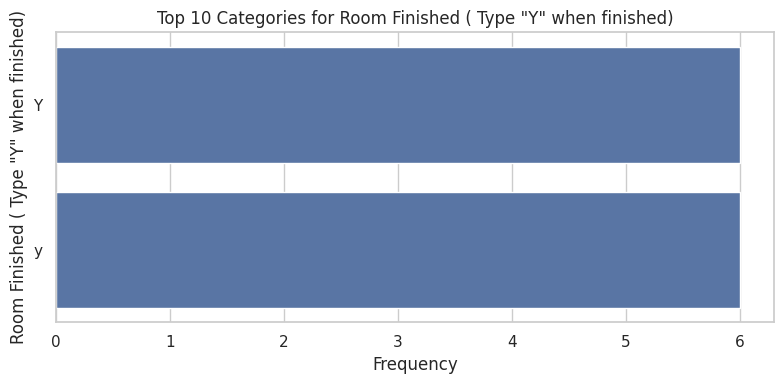

In [ ]:
# Exclude identifier variables from categorical analysis
categorical_vars_clean = [
    col for col in categorical_vars
    if col != 'SerialKey'
]

for col in categorical_vars_clean:
    top_categories = df[col].value_counts(dropna=False).head(10)

    plt.figure(figsize=(8, 4))
    sns.barplot(x=top_categories.values, y=top_categories.index)
    plt.title(f"Top 10 Categories for {col}")
    plt.xlabel("Frequency")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

# Bivariable / Multivariable Analysis

Correlation analyses (quantitative and graphical) are performed to explore relationships among the key variables in the dataset.


**Heatmap of the correlation matrix**

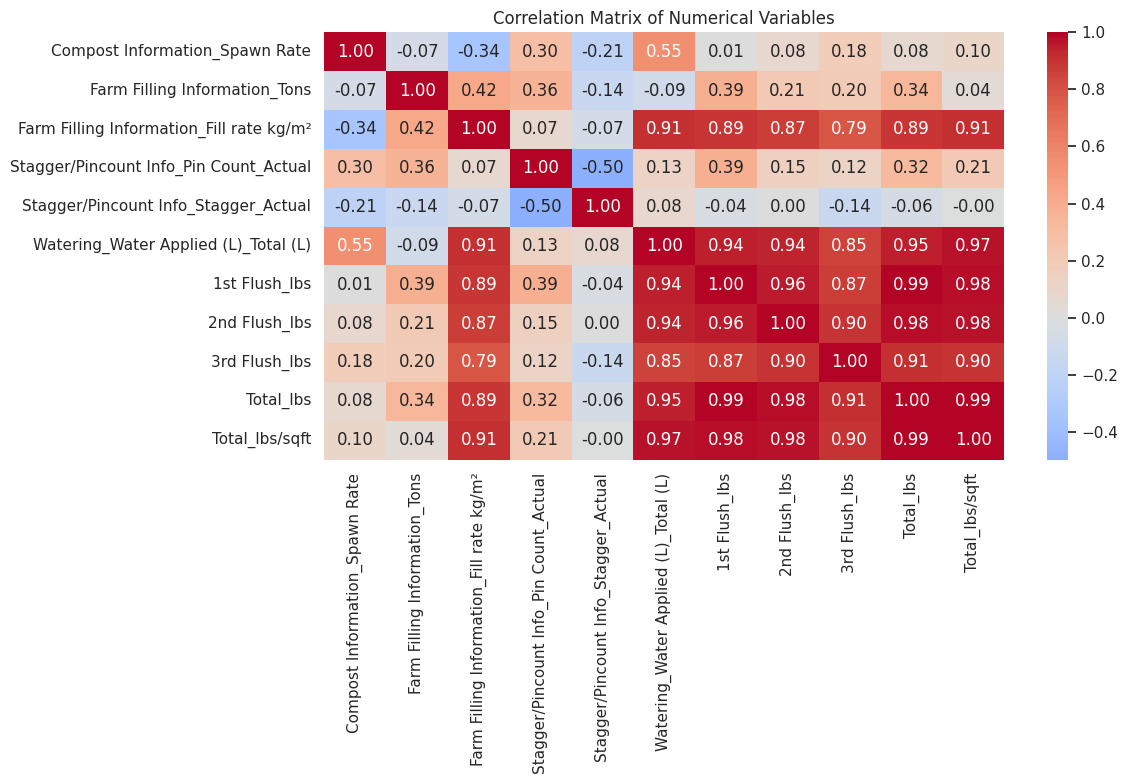

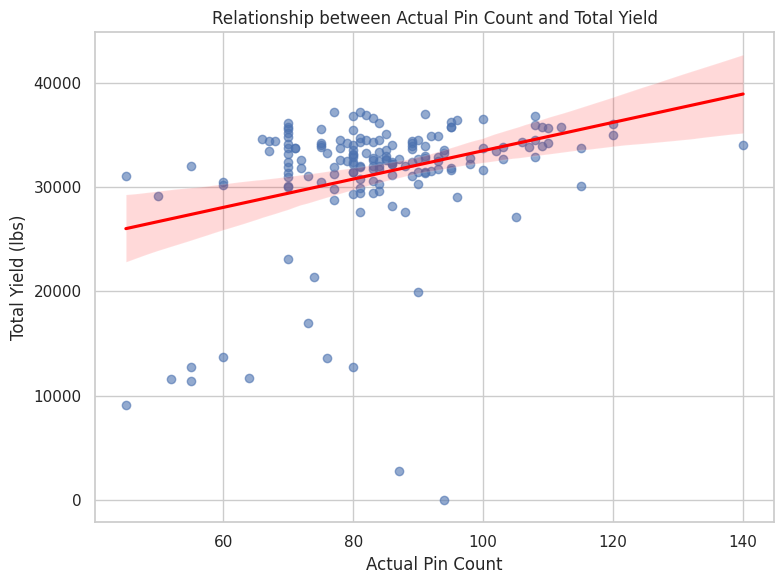

In [ ]:
# Selecting key variables for correlation
correlation_cols = [
# Inputs
    'Compost Information_Spawn Rate',
    'Farm Filling Information_Tons',
    'Farm Filling Information_Fill rate kg/m²',

    # Biological process
    'Stagger/Pincount Info_Pin Count_Actual',
    'Stagger/Pincount Info_Stagger_Actual',

    # Watering
    'Watering_Water Applied (L)_Total (L)',

    # Outputs
    '1st Flush_lbs',
    '2nd Flush_lbs',
    '3rd Flush_lbs',
    'Total_lbs',
    'Total_lbs/sqft'

]

correlation_matrix = df[correlation_cols].corr()
plt.figure(figsize=(12, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title("Correlation Matrix of Numerical Variables")
plt.tight_layout()
plt.show()


# Create a scatter plot to explore the relationship between actual pin count
# and total yield. Each point represents an individual observation in the dataset.
plt.figure(figsize=(8, 6))
sns.regplot(
    data=df,
    x='Stagger/Pincount Info_Pin Count_Actual',
    y='Total_lbs',
    scatter_kws={'alpha': 0.6},
    line_kws={'color': 'red'}
)

plt.title('Relationship between Actual Pin Count and Total Yield')
plt.xlabel('Actual Pin Count')
plt.ylabel('Total Yield (lbs)')
plt.tight_layout()
plt.show()

In [ ]:
corr_pairs = (
    correlation_matrix
    .where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)

corr_pairs.columns = ['Variable 1', 'Variable 2', 'Correlation']

# Sort by absolute correlation strength
strong_correlations = corr_pairs.reindex(
    corr_pairs['Correlation'].abs().sort_values(ascending=False).index
)

# Display top correlations
strong_correlations.head(10)


,Variable 1,Variable 2,Correlation
47,1st Flush_lbs,Total_lbs,0.993090
54,Total_lbs,Total_lbs/sqft,0.989229
50,2nd Flush_lbs,Total_lbs,0.981610
48,1st Flush_lbs,Total_lbs/sqft,0.980501
51,2nd Flush_lbs,Total_lbs/sqft,0.975531
44,Watering_Water Applied (L)_Total (L),Total_lbs/sqft,0.970922
45,1st Flush_lbs,2nd Flush_lbs,0.957454
43,Watering_Water Applied (L)_Total (L),Total_lbs,0.950900
40,Watering_Water Applied (L)_Total (L),1st Flush_lbs,0.944194
41,Watering_Water Applied (L)_Total (L),2nd Flush_lbs,0.939102


**Correlations with Total Yield**

In [ ]:
target_var = 'Total_lbs'

yield_correlations = (
    correlation_matrix[target_var]
    .drop(target_var)
    .sort_values(key=abs, ascending=False)
)

yield_correlations

,Total_lbs
1st Flush_lbs,0.993090
Total_lbs/sqft,0.989229
2nd Flush_lbs,0.981610
Watering_Water Applied (L)_Total (L),0.950900
3rd Flush_lbs,0.909467
Farm Filling Information_Fill rate kg/m²,0.890439
Farm Filling Information_Tons,0.339615
Stagger/Pincount Info_Pin Count_Actual,0.320182
Compost Information_Spawn Rate,0.080632
Stagger/Pincount Info_Stagger_Actual,-0.055144


The correlation and graphical analyses highlight several relevant relationships between operational, biological, and yield-related variables.

**Yield-related variables**

* 1st Flush_lbs and 2nd Flush_lbs show very strong positive correlations with
Total_lbs, indicating that early flush performance contributes most significantly to overall yield.

* 3rd Flush_lbs also presents a strong positive correlation with total yield, although its contribution is comparatively lower.

* Total_lbs/sqft is highly correlated with Total_lbs, suggesting that efficiency-based metrics closely follow absolute production levels.

**Water management**

Watering_Water Applied (L)_Total (L) exhibits a strong positive correlation with:

* Total_lbs

* Total_lbs/sqft

* Per-flush yields. This relationship highlights the importance of cumulative irrigation practices in supporting yield performance.

**Substrate filling characteristics**

* Farm Filling Information_Fill rate kg/m² shows a strong positive association with:

  - Total_lbs

  - Total_lbs/sqft
This suggests that substrate loading density is a key operational factor influencing productivity.

**Biological indicators**

* Stagger/Pincount Info_Pin Count_Actual demonstrates a moderate positive correlation with Total_lbs, supported by the scatter plot and regression trend.

* The dispersion observed in the scatter plot indicates that pin count alone does not fully explain yield variability and should be considered alongside other operational factors.

**Variables with limited association**

* Compost Information_Spawn Rate shows a weak correlation with total yield in this dataset.

* Stagger/Pincount Info_Stagger_Actual presents negligible or slightly negative correlations, indicating a limited direct linear relationship at the exploratory level.

# Preprocessing

Strategies for handling missing values, outliers, and high cardinality (if applicable) are implemented and justified.

In [ ]:
# Track initial dataset shape
initial_shape = df.shape

# Remove columns with all missing values
cols_all_missing = df.columns[df.isnull().mean() == 1.0].tolist()
df_cleaned = df.drop(columns=cols_all_missing)

# Remove identifier and control columns
removed_id_cols = ['SerialKey', 'Room Finished ( Type "Y" when finished)']
df_cleaned = df_cleaned.drop(columns=removed_id_cols, errors='ignore')

# Identify numerical columns (may include duplicate names)
numerical_cols = df_cleaned.select_dtypes(include=[np.number]).columns

# Count missing numeric values BEFORE imputation
missing_before = int(df_cleaned[numerical_cols].isnull().sum().sum())

# Impute missing values in numerical variables using the median
for col in numerical_cols:
    df_cleaned[col] = df_cleaned[col].fillna(df_cleaned[col].median())

# Outlier treatment using IQR-based capping
outlier_count = 0

for col in numerical_cols:
    # IMPORTANT: df_cleaned[col] may be a DataFrame if column names are duplicated.
    # Convert to NumPy to count outlier values safely in all cases.
    values = np.asarray(df_cleaned[col])

    Q1 = np.nanquantile(values, 0.25)
    Q3 = np.nanquantile(values, 0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Count how many values fall outside the bounds (value-level count)
    outlier_count += int(np.sum((values < lower_bound) | (values > upper_bound)))

    # Apply capping (np.where keeps the structure stable)
    df_cleaned[col] = np.where(
        df_cleaned[col] < lower_bound, lower_bound,
        np.where(df_cleaned[col] > upper_bound, upper_bound, df_cleaned[col])
    )

# Track final dataset shape
final_shape = df_cleaned.shape

# Preprocessing Summary
print(f"Filled {missing_before} missing values in numeric columns.")
print(f"Removed {len(cols_all_missing)} columns with no data: {cols_all_missing}")
print(f"Removed identifier/control columns: {removed_id_cols}")
print(f"Number of outlier values capped across all numeric variables: {outlier_count}")
print(f"Dataset shape changed from {initial_shape} to {final_shape}.")

Filled 4546 missing values in numeric columns.
Removed 7 columns with no data: ['1st Flush_Total Hours', '1st Flush_lbs/hr', '2nd Flush_total hours', '2nd Flush_lbs/hr', '3rd Flush_total hours', '3rd Flush_lbs/hr', 'Total_lbs/hour']
Removed identifier/control columns: ['SerialKey', 'Room Finished ( Type "Y" when finished)']
Number of outlier values capped across all numeric variables: 1861
Dataset shape changed from (266, 72) to (266, 63).


In [ ]:
# Final validation of the preprocessed dataset
print(f"Dataset Shape: {df_cleaned.shape}")
df_cleaned.info()
df_cleaned.describe()

Dataset Shape: (266, 63)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 266 entries, 0 to 265
Data columns (total 63 columns):
 #   Column                                         Non-Null Count  Dtype         
---  ------                                         --------------  -----         
 0   Compost Information_Spawn Rate                 266 non-null    float64       
 1   Compost Information_Supplement Rate            69 non-null     object        
 2   Compost Information_Water Added                68 non-null     object        
 3   Farm Filling Information_Sqft Filled           266 non-null    float64       
 4   Farm Filling Information_Missing Sections      266 non-null    float64       
 5   Farm Filling Information_Sqm Filled            266 non-null    float64       
 6   Farm Filling Information_Tons                  266 non-null    float64       
 7   Farm Filling Information_Filled heights (cm)   175 non-null    object        
 8   Farm Filling Information_Filled kg 

,Compost Information_Spawn Rate,Farm Filling Information_Sqft Filled,Farm Filling Information_Missing Sections,Farm Filling Information_Sqm Filled,Farm Filling Information_Tons,Farm Filling Information_Filled kg,Farm Filling Information_Fill rate kg/m²,Farm Filling Information_Loading Date,Stagger/Pincount Info_Picking Date,Stagger/Pincount Info_Picking Day_Actual,...,3rd Flush_Day 7,3rd Flush_Day 8,3rd Flush_Day 9,3rd Flush_lbs,3rd Flush_lbs/sqft,3rd Flush_lbs/ton,Total_lbs,Total_lbs/sqft,Total_lbs/ton,Total_Target
count,2.660000e+02,266.000000,266.0,266.000000,266.000000,266.000000,266.000000,175,175,266.0,...,266.0,266.0,266.0,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.0
mean,1.501535e+01,4654.545823,2.0,432.417858,38.098896,24358.609023,58.086502,2025-06-29 12:04:06.857142784,2025-07-14 06:10:17.142857216,16.0,...,0.0,0.0,0.0,1961.095376,0.432121,89.557936,19775.474737,4.355725,860.530376,820.0
min,1.501535e+01,4564.828755,2.0,424.082939,34.748750,0.000000,0.000000,2024-12-25 00:00:00,2025-01-09 00:00:00,16.0,...,0.0,0.0,0.0,0.000000,0.000000,67.874219,0.000000,0.000000,779.535565,820.0
25%,1.501535e+01,4629.731502,2.0,430.112551,37.242500,0.000000,0.000000,2025-03-29 00:00:00,2025-04-13 00:00:00,16.0,...,0.0,0.0,0.0,0.000000,0.000000,84.026418,0.000000,0.000000,841.169312,820.0
50%,1.501535e+01,4673.000000,2.0,434.132293,38.185000,36430.000000,85.043201,2025-07-02 00:00:00,2025-07-16 00:00:00,16.0,...,0.0,0.0,0.0,2779.770000,0.626688,90.833532,30528.755000,6.663431,863.335895,820.0
75%,1.501535e+01,4673.000000,2.0,434.132293,38.905000,38905.000000,90.156850,2025-09-29 12:00:00,2025-10-14 00:00:00,16.0,...,0.0,0.0,0.0,3589.485000,0.777382,94.794551,33519.875000,7.216355,882.258477,820.0
max,1.501535e+01,4673.000000,2.0,434.132293,41.398750,45750.000000,105.382624,2025-12-29 00:00:00,2026-01-13 00:00:00,16.0,...,0.0,0.0,0.0,4977.580000,1.065179,110.946750,37156.920000,8.266538,943.892224,820.0
std,8.186644e-14,30.498967,0.0,2.833423,1.578414,18169.546114,42.489120,NaN,NaN,0.0,...,0.0,0.0,0.0,1782.812252,0.385457,11.428086,15909.675445,3.430642,44.210820,0.0


Data preprocessing was conducted to improve data quality and ensure reliable analysis. Columns with 100% missing values, as well as identifier and control variables, were removed due to their lack of analytical relevance. Missing values in numerical variables were imputed using the median to maintain robustness against outliers. Extreme values were treated using an IQR-based capping approach to reduce their influence while preserving all observations. These steps resulted in a clean and consistent dataset suitable for exploratory and correlation analysis.

# Analysis with clean data set
Now that the data is cleaner, we repeat the analysis to see the impact on the results

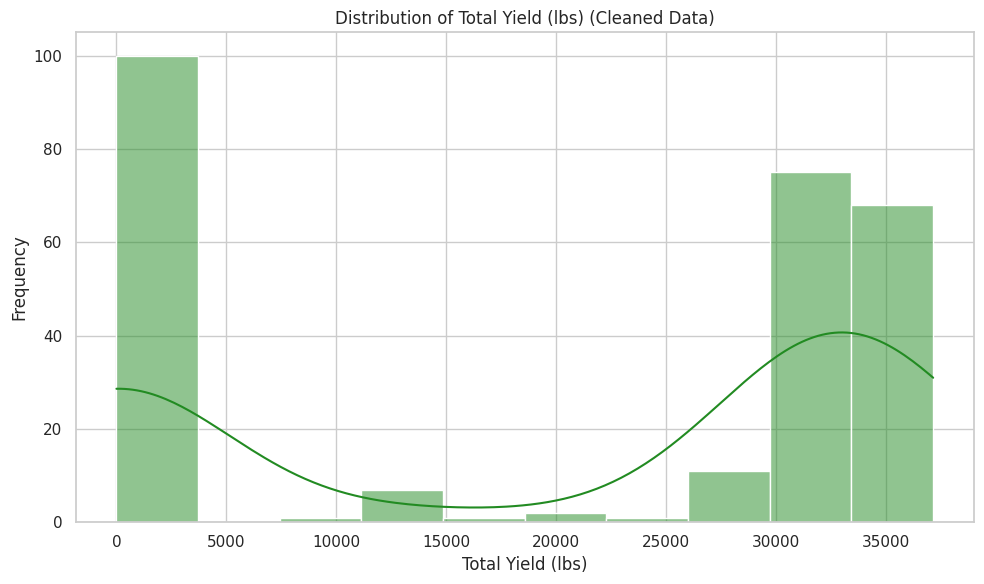

Skipping Boxplot: Spawn Rate and/or Total_lbs is missing, not numeric, or has insufficient variability in df_cleaned.


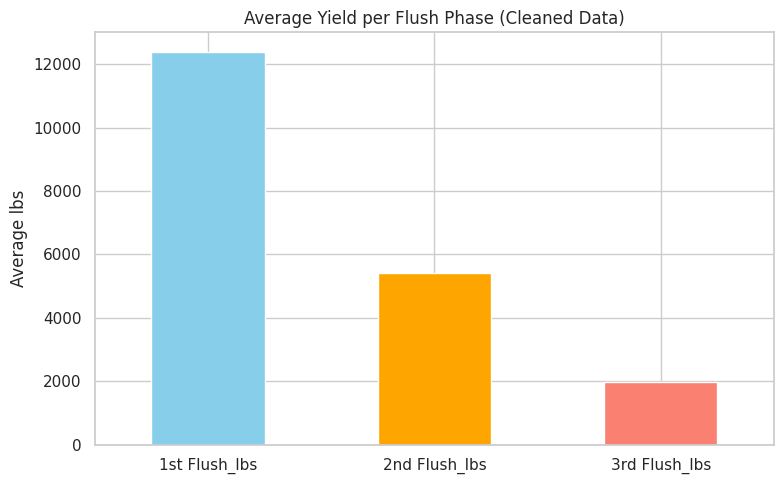

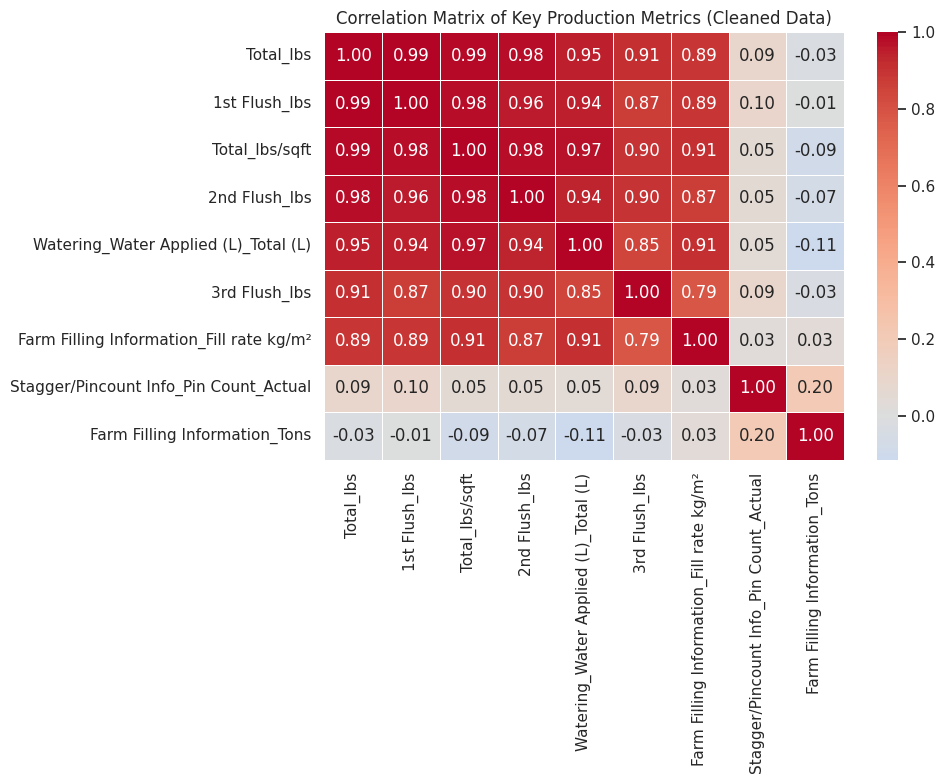

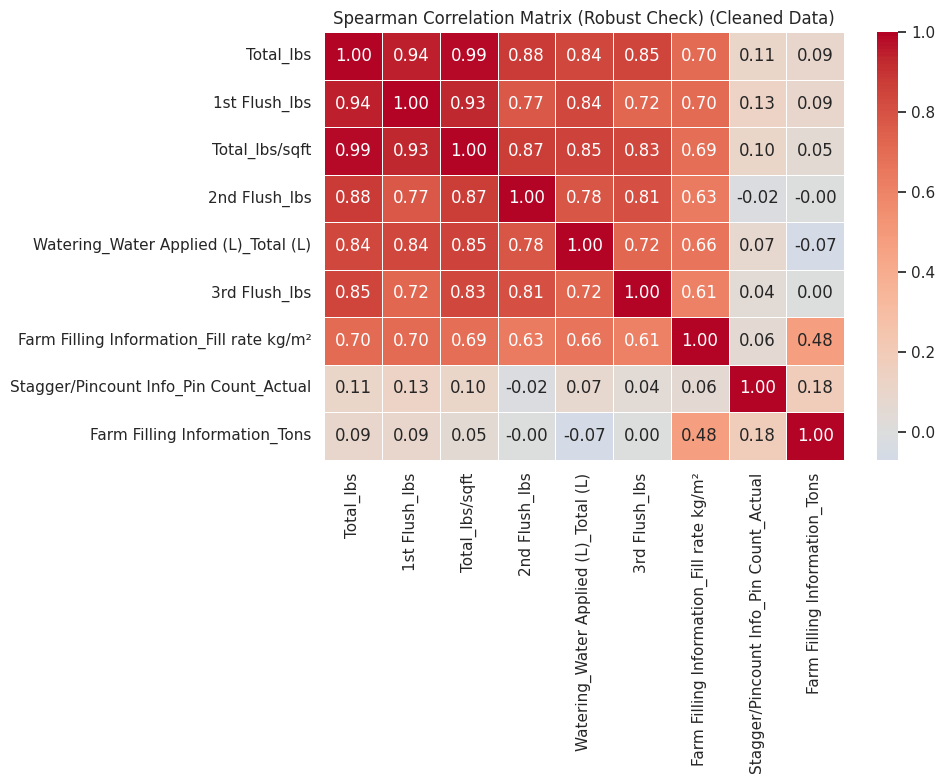

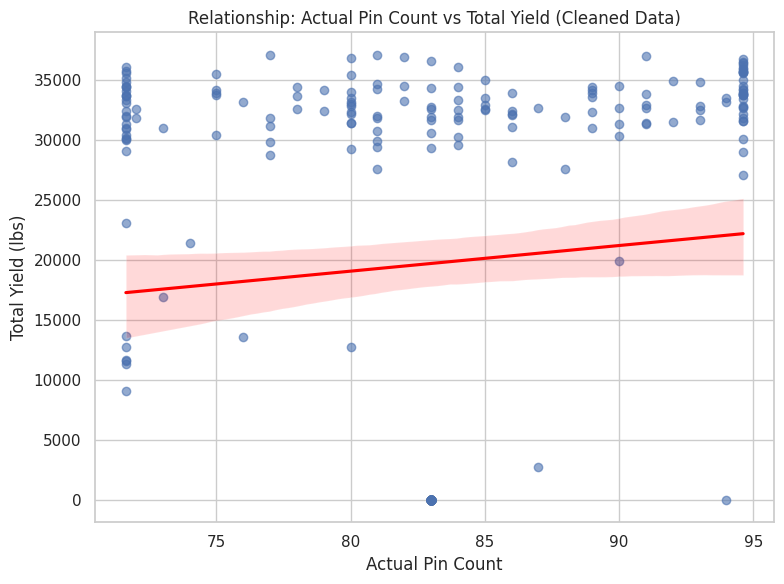

In [ ]:
sns.set_theme(style="whitegrid")

# 1. Histogram: Distribution of Total Yield (lbs) using the cleaned dataset
if 'Total_lbs' in df_cleaned.columns and pd.api.types.is_numeric_dtype(df_cleaned['Total_lbs']):
    plt.figure(figsize=(10, 6))
    sns.histplot(df_cleaned['Total_lbs'].dropna(), kde=True, color='forestgreen')
    plt.title('Distribution of Total Yield (lbs) (Cleaned Data)')
    plt.xlabel('Total Yield (lbs)')
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()
else:
    print("Skipping Histogram: 'Total_lbs' is missing or not numeric in df_cleaned.")

# 2. Boxplot: Yield distribution across Spawn Rate bins (only if Spawn Rate has enough variability)
if ('Compost Information_Spawn Rate' in df_cleaned.columns and
    pd.api.types.is_numeric_dtype(df_cleaned['Compost Information_Spawn Rate']) and
    df_cleaned['Compost Information_Spawn Rate'].nunique(dropna=True) > 1 and
    'Total_lbs' in df_cleaned.columns and
    pd.api.types.is_numeric_dtype(df_cleaned['Total_lbs'])):

    plt.figure(figsize=(12, 6))
    sns.boxplot(
        x=pd.cut(df_cleaned['Compost Information_Spawn Rate'], bins=5),
        y=df_cleaned['Total_lbs']
    )
    plt.title('Yield Distribution by Spawn Rate Bins (Cleaned Data)')
    plt.xlabel('Spawn Rate (binned)')
    plt.ylabel('Total Yield (lbs)')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("Skipping Boxplot: Spawn Rate and/or Total_lbs is missing, not numeric, or has insufficient variability in df_cleaned.")

# 3. Bar Chart: Average yield per flush phase (cleaned data)
flush_cols = ['1st Flush_lbs', '2nd Flush_lbs', '3rd Flush_lbs']
existing_flush_cols = [c for c in flush_cols if c in df_cleaned.columns and pd.api.types.is_numeric_dtype(df_cleaned[c])]

if len(existing_flush_cols) >= 2:
    flush_means_cleaned = df_cleaned[existing_flush_cols].mean()
    plt.figure(figsize=(8, 5))
    flush_means_cleaned.plot(kind='bar', color=['skyblue', 'orange', 'salmon'][:len(existing_flush_cols)])
    plt.title('Average Yield per Flush Phase (Cleaned Data)')
    plt.ylabel('Average lbs')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()
else:
    print("Skipping Bar Chart: Not enough flush yield columns are available and numeric in df_cleaned.")

# 4. Correlation analysis (cleaned data): key variables only, with near-zero variance removal and optional target-based ordering
key_corr_cols = [
    # Inputs
    'Compost Information_Spawn Rate',
    'Farm Filling Information_Tons',
    'Farm Filling Information_Fill rate kg/m²',

    # Biological process
    'Stagger/Pincount Info_Pin Count_Actual',
    'Stagger/Pincount Info_Stagger_Actual',

    # Watering
    'Watering_Water Applied (L)_Total (L)',

    # Outputs
    '1st Flush_lbs',
    '2nd Flush_lbs',
    '3rd Flush_lbs',
    'Total_lbs',
    'Total_lbs/sqft'

]

# Keep only existing numeric columns
existing_corr_cols = [
    c for c in key_corr_cols
    if c in df_cleaned.columns and pd.api.types.is_numeric_dtype(df_cleaned[c])
]

# Remove near-zero variance columns (correlation would be unstable or undefined)
existing_corr_cols = [
    c for c in existing_corr_cols
    if df_cleaned[c].dropna().std() > 1e-6
]

if len(existing_corr_cols) > 1:
    # Pearson correlation (linear association)
    corr_matrix_cleaned = df_cleaned[existing_corr_cols].corr(method='pearson')

    # Reorder the matrix by correlation with the target variable (if present)
    target_var = 'Total_lbs'
    if target_var in corr_matrix_cleaned.columns:
        ordered = corr_matrix_cleaned[target_var].abs().sort_values(ascending=False).index
        corr_matrix_cleaned = corr_matrix_cleaned.loc[ordered, ordered]

    # Heatmap visualization
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix_cleaned, annot=True, cmap='coolwarm', fmt=".2f", center=0, linewidths=0.5)
    plt.title('Correlation Matrix of Key Production Metrics (Cleaned Data)')
    plt.tight_layout()
    plt.show()

    # Spearman correlation (rank-based robustness check)
    corr_matrix_cleaned_spearman = df_cleaned[existing_corr_cols].corr(method='spearman')
    if target_var in corr_matrix_cleaned_spearman.columns:
        corr_matrix_cleaned_spearman = corr_matrix_cleaned_spearman.loc[corr_matrix_cleaned.index, corr_matrix_cleaned.columns]

    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix_cleaned_spearman, annot=True, cmap='coolwarm', fmt=".2f", center=0, linewidths=0.5)
    plt.title('Spearman Correlation Matrix (Robust Check) (Cleaned Data)')
    plt.tight_layout()
    plt.show()
else:
    print("Skipping Correlation Matrices: Insufficient numeric, non-constant columns for correlation after cleaning.")

# 5. Quantitative relationship: Pin Count vs Total Yield (cleaned data), including regression trend
if ('Stagger/Pincount Info_Pin Count_Actual' in df_cleaned.columns and
    'Total_lbs' in df_cleaned.columns and
    pd.api.types.is_numeric_dtype(df_cleaned['Stagger/Pincount Info_Pin Count_Actual']) and
    pd.api.types.is_numeric_dtype(df_cleaned['Total_lbs'])):

    plt.figure(figsize=(8, 6))
    sns.regplot(
        data=df_cleaned,
        x='Stagger/Pincount Info_Pin Count_Actual',
        y='Total_lbs',
        scatter_kws={'alpha': 0.6},
        line_kws={'color': 'red'}
    )
    plt.title('Relationship: Actual Pin Count vs Total Yield (Cleaned Data)')
    plt.xlabel('Actual Pin Count')
    plt.ylabel('Total Yield (lbs)')
    plt.tight_layout()
    plt.show()
else:
    print("Skipping Scatter/Regression Plot: Required columns are missing or not numeric in df_cleaned.")

**Top Pairwise Correlations Between Numerical Variables**

In [ ]:
corr_pairs = (
    correlation_matrix
    .where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)

corr_pairs.columns = ['Variable 1', 'Variable 2', 'Correlation']

# Sort by absolute correlation strength
strong_correlations = corr_pairs.reindex(
    corr_pairs['Correlation'].abs().sort_values(ascending=False).index
)
# Display top correlations
strong_correlations.head(10)

,Variable 1,Variable 2,Correlation
47,1st Flush_lbs,Total_lbs,0.993090
54,Total_lbs,Total_lbs/sqft,0.989229
50,2nd Flush_lbs,Total_lbs,0.981610
48,1st Flush_lbs,Total_lbs/sqft,0.980501
51,2nd Flush_lbs,Total_lbs/sqft,0.975531
44,Watering_Water Applied (L)_Total (L),Total_lbs/sqft,0.970922
45,1st Flush_lbs,2nd Flush_lbs,0.957454
43,Watering_Water Applied (L)_Total (L),Total_lbs,0.950900
40,Watering_Water Applied (L)_Total (L),1st Flush_lbs,0.944194
41,Watering_Water Applied (L)_Total (L),2nd Flush_lbs,0.939102


**Correlation of Key Variables with Total Yield (Total_lbs)**

In [ ]:
target_var = 'Total_lbs'

yield_correlations = (
    correlation_matrix[target_var]
    .drop(target_var)
    .sort_values(key=abs, ascending=False)
)

yield_correlations

,Total_lbs
1st Flush_lbs,0.993090
Total_lbs/sqft,0.989229
2nd Flush_lbs,0.981610
Watering_Water Applied (L)_Total (L),0.950900
3rd Flush_lbs,0.909467
Farm Filling Information_Fill rate kg/m²,0.890439
Farm Filling Information_Tons,0.339615
Stagger/Pincount Info_Pin Count_Actual,0.320182
Compost Information_Spawn Rate,0.080632
Stagger/Pincount Info_Stagger_Actual,-0.055144


# Conclusions

**Univariable Analysis (Cleaned Data)**

* **Total Yield (lbs) Distribution:**

  Using the cleaned dataset, the histogram of Total_lbs shows a more representative distribution of production outcomes. The removal of extreme and missing-value distortions results in clearer yield ranges and improved interpretability of typical production behavior.

* **Spawn Rate Impact:**

  The boxplot analysis with cleaned data indicates that Compost Information_Spawn Rate exhibits limited variability in its relationship with Total_lbs. Its relatively stable behavior across bins suggests that spawn rate is not a primary driver of yield variability within this dataset.

* **Yield per Flush Phase:**

  The bar chart based on cleaned data consistently shows that 1st Flush_lbs contributes the largest share of total yield, followed by 2nd Flush_lbs and 3rd Flush_lbs. This pattern remains stable after preprocessing, highlighting the importance of early production stages.

**Multivariable Analysis (Cleaned Correlation and Pairwise Analysis)**

* Total Yield (Total_lbs) and Total_lbs/sqft (Cleaned Data):

  * 1st Flush_lbs, 2nd Flush_lbs, and 3rd Flush_lbs maintain very strong positive correlations with total yield, confirming that total production is primarily driven by flush-level performance, particularly during the first flush.

  * Farm Filling Information_Filled kg and Farm Filling Information_Fill rate kg/m² show strong positive correlations with yield metrics, reinforcing the importance of substrate quantity and loading density after noise reduction.

  * Watering_Water Applied (L)_Total (L) remains strongly correlated with total yield, likely reflecting operational scale rather than a direct causal effect.

  * Stagger/Pincount Info_Pin Count_Actual shows a moderate positive correlation with yield, supporting its role as a biological indicator of productive capacity in the cleaned dataset.

  * Compost Information_Spawn Rate and Stagger/Pincount Info_Stagger_Actual continue to display weak or negligible linear relationships with total yield.

* Pairwise Correlation Analysis (Cleaned Data):
The strongest pairwise correlations occur among yield-related variables, indicating redundancy and potential multicollinearity. This confirms that, after cleaning, the dataset retains consistent production relationships while emphasizing the need for careful feature selection in future modeling.